# 04 - Text Extraction (OCR)

This notebook shows how to use OCI Vision's text detection (OCR) feature.
The project now ships with a real demo fixture for OCR, so this notebook runs
end to end in `demo=True` using the synthetic roadside sign asset in the gallery.


## Setup

In [1]:
# !pip install oci-vision-ai[notebooks]

from oci_vision.core.client import VisionClient

client = VisionClient(demo=True)
print(f"Client ready (demo={client.is_demo})")

Client ready (demo=True)


## Run the analysis

The `detect_text()` method sends an image to OCI Vision's `TEXT_DETECTION`
feature. In demo mode we can use the bundled `sign_board.png` fixture and get a
real `TextDetectionResult` back.


In [2]:
result = client.detect_text("sign_board.png")
print(f"Model version: {result.model_version}")
print(f"Lines detected: {len(result.lines)}")
print()
print(result.full_text)

Model version: 1.0.0
Lines detected: 2

STOP
SCHOOL XING


## Explore the results

Let's inspect the normalized OCR structure. Each line contains text,
confidence, a bounding polygon, and any matched words.


In [3]:
from oci_vision.core.models import TextLine, TextWord

print(type(result).__name__)
print()
for i, line in enumerate(result.lines, 1):
    print(f"Line {i}: {line.text!r}")
    print(f"  Confidence: {line.confidence:.1%}")
    print(f"  Position:   {line.bounding_polygon.human_position(900, 600)}")
    print(f"  Words:      {[word.text for word in line.words]}")
    print()

TextDetectionResult

Line 1: 'STOP'
  Confidence: 99.0%
  Position:   top-left
  Words:      ['STOP']

Line 2: 'SCHOOL XING'
  Confidence: 97.0%
  Position:   center
  Words:      ['SCHOOL', 'XING']



In [4]:
# Iterate over lines and words in a more tabular way
for i, line in enumerate(result.lines, 1):
    print(f"Line {i}: {line.text}")
    for j, word in enumerate(line.words, 1):
        verts = word.bounding_polygon.to_pixels(900, 600)
        print(f"  Word {j}: {word.text!r} ({word.confidence:.1%}) -> {verts}")
    print()

Line 1: STOP
  Word 1: 'STOP' (99.0%) -> [(144, 84), (432, 84), (432, 168), (144, 168)]

Line 2: SCHOOL XING
  Word 1: 'SCHOOL' (97.0%) -> [(90, 276), (396, 276), (396, 348), (90, 348)]
  Word 2: 'XING' (96.0%) -> [(432, 276), (648, 276), (648, 348), (432, 348)]



## Visualize

The renderer draws OCR regions in yellow. Here we render the overlay on top of
the bundled gallery image so the OCR output is visible end to end.


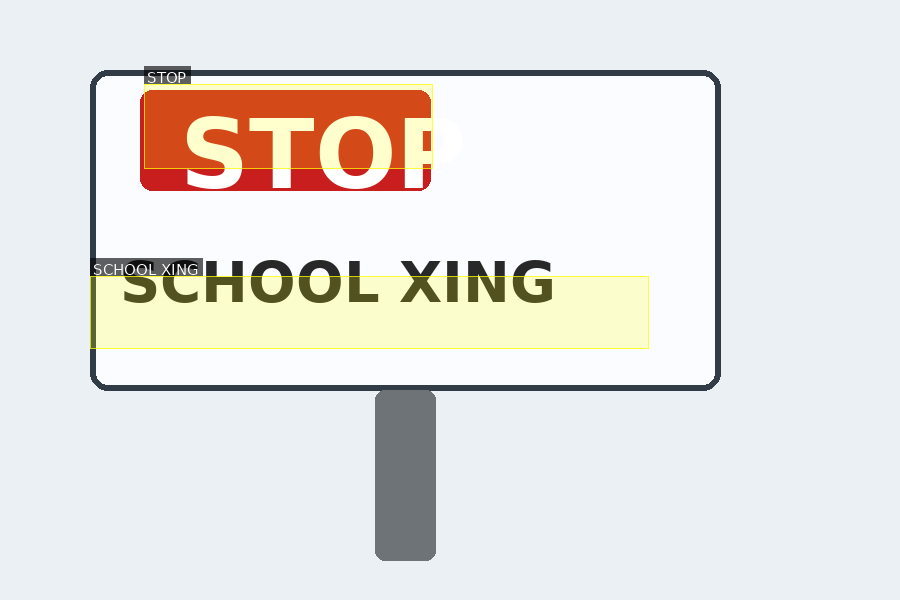

In [5]:
from pathlib import Path
from PIL import Image

from oci_vision.core.models import AnalysisReport
from oci_vision.core.renderer import render_overlay
from oci_vision.gallery import get_gallery_path

image_path = get_gallery_path() / "images" / "sign_board.png"
base_image = Image.open(image_path)
report = AnalysisReport(image_path=str(image_path), text=result)
overlay = render_overlay(base_image, report)
overlay

## Under the hood

In [6]:
import json

raw = result.model_dump()
print(json.dumps(raw, indent=2, default=str))

{
  "model_version": "1.0.0",
  "lines": [
    {
      "text": "STOP",
      "confidence": 0.99,
      "bounding_polygon": {
        "normalized_vertices": [
          {
            "x": 0.16,
            "y": 0.14
          },
          {
            "x": 0.48,
            "y": 0.14
          },
          {
            "x": 0.48,
            "y": 0.28
          },
          {
            "x": 0.16,
            "y": 0.28
          }
        ],
        "center": [
          0.32,
          0.21000000000000002
        ]
      },
      "words": [
        {
          "text": "STOP",
          "confidence": 0.99,
          "bounding_polygon": {
            "normalized_vertices": [
              {
                "x": 0.16,
                "y": 0.14
              },
              {
                "x": 0.48,
                "y": 0.14
              },
              {
                "x": 0.48,
                "y": 0.28
              },
              {
                "x": 0.16,
              

### Live API usage pattern

When using real OCI credentials, the call is the same:

```python
client = VisionClient()  # uses ~/.oci/config
result = client.detect_text("path/to/image.jpg")
print(result.full_text)
```

If you want to add a new OCR example to demo mode later, use the CLI recorder:

```bash
oci-vision record-demo ./my-sign.png --feature text --response-json ./ocr.json
```


## Try it yourself

1. Swap `sign_board.png` for a live photo or receipt and rerun the notebook.
2. Export `result.model_dump_json(indent=2)` for downstream tooling.
3. Save the overlay image with `overlay.save('ocr_overlay.png')`.
4. Compare OCR output with `oci-vision eval text pred.json truth.json`.
